In [11]:
# IMPORT LIBRARIES
import os
import random
import shutil
import time

# Numerical Libraries
import numpy as np

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split

# Torchvision
from torchvision import datasets, transforms, models

# Image + Visualization
from PIL import Image
import matplotlib.pyplot as plt

from tqdm import tqdm

In [12]:

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [13]:
base_path = "./data/food-101/food-101"

for root, dirs, files in os.walk(base_path):
    print(f"\n {root}")
    print(f"   Subfolders: {len(dirs)}")
    print(f"   Files: {len(files)}")
    break  # only top level


 ./data/food-101/food-101
   Subfolders: 2
   Files: 2


In [14]:
# Check what's inside
print("\nImages folder:")
print(os.listdir(base_path + "/images")[:5])

print("\nMeta folder:")
print(os.listdir(base_path + "/meta"))


Images folder:
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']

Meta folder:
['classes.txt', 'labels.txt', 'test.json', 'test.txt', 'train.json', 'train.txt']


In [15]:
# Load class names from dataset directory

classes = os.listdir(base_path + "/images")
classes = [c for c in classes if os.path.isdir(os.path.join(base_path, "images", c))]

# Display dataset summary information

print("Number of classes:", len(classes))
print("Sample classes:", classes[:10])

Number of classes: 101
Sample classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


In [16]:

class Food101Dataset(Dataset):
    def __init__(self, root, split="train", transform=None):
        self.root = root
        self.transform = transform
        
        # Load split file
        split_file = os.path.join(root, "meta", f"{split}.txt")
        
        with open(split_file, "r") as f:
            self.image_paths = [line.strip() for line in f.readlines()]
        
        # Extract class names
        self.classes = sorted(list(set([p.split("/")[0] for p in self.image_paths])))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = path.split("/")[0]
        
        img_path = os.path.join(self.root, "images", path + ".jpg")
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, self.class_to_idx[label]

In [17]:
# Resize all images to match pretrained CNN input size and convert to tensors

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

data_root = "./data/food-101/food-101"

# Load official Food101 train and test splits

train_dataset = Food101Dataset(data_root, split="train", transform=transform)
test_dataset = Food101Dataset(data_root, split="test", transform=transform)

# Initial loaders used to verify dataset loading before train/validation split

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Number of classes:", len(train_dataset.classes))

Train size: 75750
Test size: 25250
Number of classes: 101


In [18]:

# PART 1: TRAIN / VALIDATION SPLIT + REDUCED DATASET + DATALOADERS


# 1. Set random seed

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# 2. Set device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# 3. Train / Validation split

val_ratio = 0.1
train_size = int((1 - val_ratio) * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)


# 4. Reduced dataset 
from torch.utils.data import Subset
train_subset_small = Subset(train_subset, range(10000))
val_subset_small = Subset(val_subset, range(2000))

print("Reduced train subset size:", len(train_subset_small))
print("Reduced validation subset size:", len(val_subset_small))


# 5. DataLoaders 

batch_size = 32

train_loader = DataLoader(
    train_subset_small,  
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_subset_small,    
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)


# 6. Print summary

print("Train subset size:", len(train_subset_small))
print("Validation subset size:", len(val_subset_small))
print("Test size:", len(test_dataset))
print("Batch size:", batch_size)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Using device: cuda
Reduced train subset size: 10000
Reduced validation subset size: 2000
Train subset size: 10000
Validation subset size: 2000
Test size: 25250
Batch size: 32
Train batches: 313
Validation batches: 63
Test batches: 790


In [19]:

#PART 2:CHECK


# Get one batch
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)
print("Min pixel value:", images.min().item())
print("Max pixel value:", images.max().item())
print("Sample labels:", labels[:10].tolist())

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64
Min pixel value: 0.0
Max pixel value: 1.0
Sample labels: [13, 92, 81, 37, 41, 96, 3, 30, 84, 34]


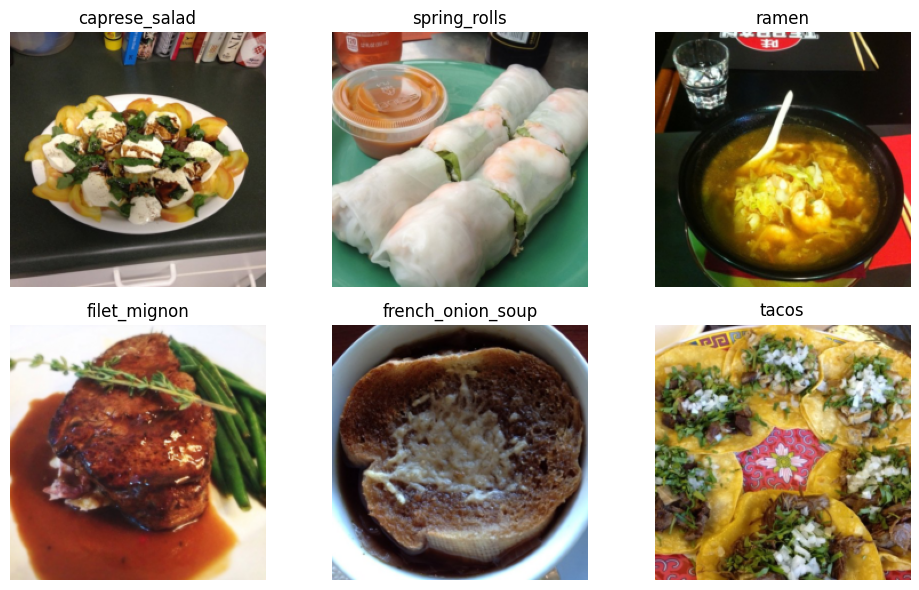

In [20]:

# VISUALIZE SAMPLE IMAGES



fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for i in range(6):
    img = images[i].permute(1, 2, 0).numpy()
    label = labels[i].item()

    axes[i // 3, i % 3].imshow(img)
    axes[i // 3, i % 3].set_title(train_dataset.classes[label])
    axes[i // 3, i % 3].axis("off")

plt.tight_layout()
plt.show()

In [21]:

# PART 3: TRAINING FRAMEWORK


# 1. Loss function

criterion = nn.CrossEntropyLoss()


# 2. Accuracy function
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)


# 3. Train one epoch

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        # Handle models like GoogLeNet
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += calculate_accuracy(outputs, labels)

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    return epoch_loss, epoch_acc


# 4. Evaluation

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, labels)

            running_loss += loss.item()
            running_acc += calculate_accuracy(outputs, labels)

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    return epoch_loss, epoch_acc

# 5. Full training loop

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=5):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
        print("-" * 50)

    total_time = time.time() - start_time

    return history, total_time


# 6. Plot function


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

print("Training framework ready.")

Training framework ready.


In [22]:

# PART 4A: CUSTOM CLASSIFIER


class CustomClassifier(nn.Module):
    def __init__(self, in_features, num_classes=101):
        super(CustomClassifier, self).__init__()

        self.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.fc(x)

print("Custom classifier ready.")

Custom classifier ready.


In [23]:

# PART 4B: RESNET18 SETUP (TRANSFER LEARNING)

# 1. Load pretrained model

resnet = models.resnet18(pretrained=True)


# 2. Freeze backbone

for param in resnet.parameters():
    param.requires_grad = False


# 3. Replace final layer

in_features = resnet.fc.in_features
resnet.fc = CustomClassifier(in_features)


# 4. Move to device

resnet = resnet.to(device)

print("ResNet18 ready.")

c:\Users\mites\Downloads\DeepLearning_A2\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\mites\Downloads\DeepLearning_A2\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet18 ready.


In [24]:

# PART 4C: OPTIMIZER

optimizer = optim.Adam(resnet.fc.parameters(), lr=0.001)

print("Optimizer ready.")

Optimizer ready.


In [25]:

# PART 4D: TRAIN RESNET18


num_epochs = 2

history_resnet, resnet_training_time = train_model(
    resnet,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs
)


Epoch 1/2


Train Loss: 4.4120 | Train Acc: 0.0394
Val Loss:   3.7554 | Val Acc:   0.1310
--------------------------------------------------

Epoch 2/2


Train Loss: 3.7192 | Train Acc: 0.1233
Val Loss:   3.2583 | Val Acc:   0.2222
--------------------------------------------------


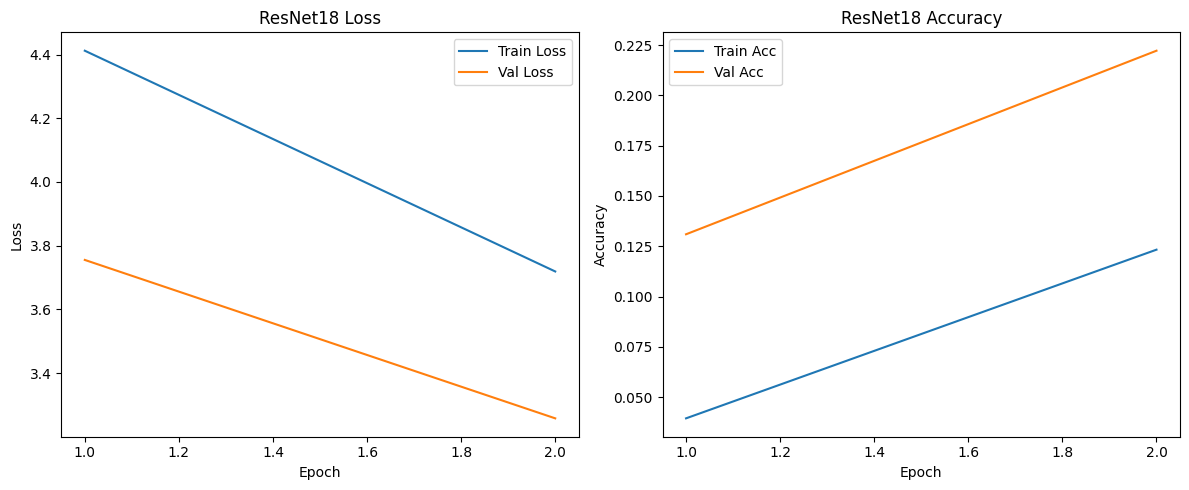

In [26]:

# PART 4E: PLOT RESULTS


plot_history(history_resnet, "ResNet18")

In [27]:

# PART 4F: TEST EVALUATION


test_loss_resnet, test_acc_resnet = evaluate(
    resnet,
    test_loader,
    criterion,
    device
)

print(f"ResNet18 Test Loss: {test_loss_resnet:.4f}")
print(f"ResNet18 Test Accuracy: {test_acc_resnet:.4f}")
print(f"ResNet18 Training Time: {resnet_training_time:.2f} seconds")

ResNet18 Test Loss: 3.1487
ResNet18 Test Accuracy: 0.2330
ResNet18 Training Time: 266.91 seconds


In [28]:

# PART 5A: MOBILENET V3 SETUP



mobilenet = models.mobilenet_v3_small(pretrained=True)

# Freeze backbone
for param in mobilenet.parameters():
    param.requires_grad = False

# Replace classifier
in_features = mobilenet.classifier[3].in_features
mobilenet.classifier[3] = CustomClassifier(in_features)

# Move to device
mobilenet = mobilenet.to(device)

print("MobileNet V3 ready.")

c:\Users\mites\Downloads\DeepLearning_A2\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MobileNet V3 ready.


In [29]:

# PART 5B: OPTIMIZER


optimizer_mobilenet = torch.optim.Adam(
    mobilenet.classifier[3].parameters(),
    lr=0.001
)

print("MobileNet optimizer ready.")

MobileNet optimizer ready.


In [30]:

# PART 5C: TRAIN MOBILENET


num_epochs = 2

history_mobilenet, mobilenet_training_time = train_model(
    mobilenet,
    train_loader,
    val_loader,
    criterion,
    optimizer_mobilenet,
    device,
    num_epochs
)


Epoch 1/2


Train Loss: 3.8766 | Train Acc: 0.1258
Val Loss:   3.1534 | Val Acc:   0.2639
--------------------------------------------------

Epoch 2/2


Train Loss: 3.0006 | Train Acc: 0.2736
Val Loss:   2.7782 | Val Acc:   0.3423
--------------------------------------------------


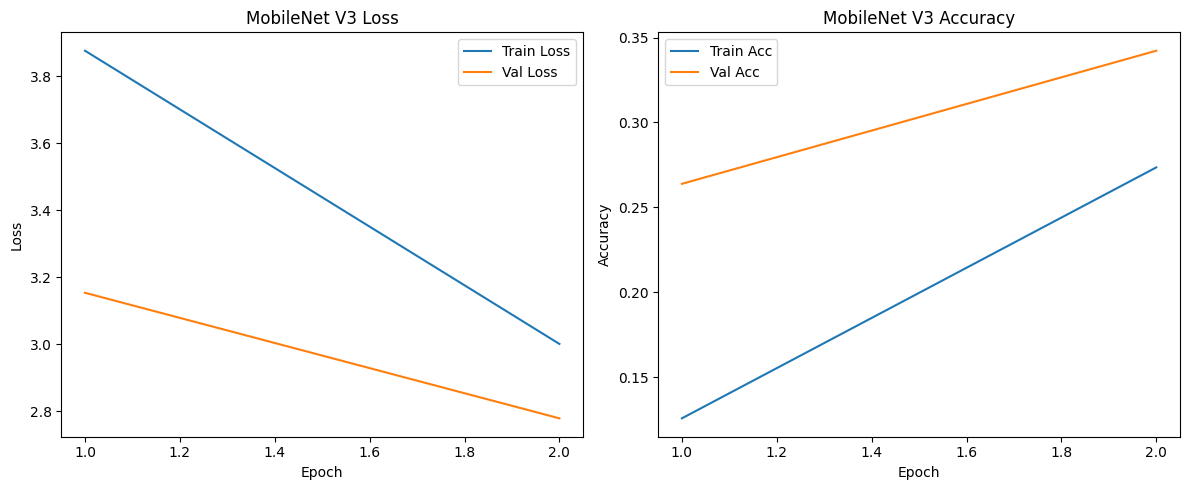

In [31]:

# PART 5D: PLOT MOBILENET RESULTS


plot_history(history_mobilenet, "MobileNet V3")

In [32]:

# PART 5E: TEST EVALUATION FOR MOBILENET V3


test_loss_mobilenet, test_acc_mobilenet = evaluate(
    mobilenet,
    test_loader,
    criterion,
    device
)

print(f"MobileNet V3 Test Loss: {test_loss_mobilenet:.4f}")
print(f"MobileNet V3 Test Accuracy: {test_acc_mobilenet:.4f}")
print(f"MobileNet V3 Training Time: {mobilenet_training_time:.2f} seconds")

MobileNet V3 Test Loss: 2.5918
MobileNet V3 Test Accuracy: 0.3593
MobileNet V3 Training Time: 268.32 seconds


In [33]:

# PART 6A: GOOGLENET SETUP

googlenet = models.googlenet(pretrained=True)

# Freeze backbone
for param in googlenet.parameters():
    param.requires_grad = False

# Replace final layer
in_features = googlenet.fc.in_features
googlenet.fc = CustomClassifier(in_features)

# Move to device
googlenet = googlenet.to(device)

print("GoogLeNet ready.")

c:\Users\mites\Downloads\DeepLearning_A2\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


GoogLeNet ready.


In [34]:

# PART 6B: OPTIMIZER

optimizer_googlenet = torch.optim.Adam(
    googlenet.fc.parameters(),
    lr=0.001
)

print("GoogLeNet optimizer ready.")

GoogLeNet optimizer ready.


In [35]:

# PART 6C: TRAIN GOOGLENET


num_epochs = 2

history_googlenet, googlenet_training_time = train_model(
    googlenet,
    train_loader,
    val_loader,
    criterion,
    optimizer_googlenet,
    device,
    num_epochs
)


Epoch 1/2


Train Loss: 4.5390 | Train Acc: 0.0253
Val Loss:   4.1504 | Val Acc:   0.0645
--------------------------------------------------

Epoch 2/2


Train Loss: 4.0009 | Train Acc: 0.0806
Val Loss:   3.5975 | Val Acc:   0.1607
--------------------------------------------------


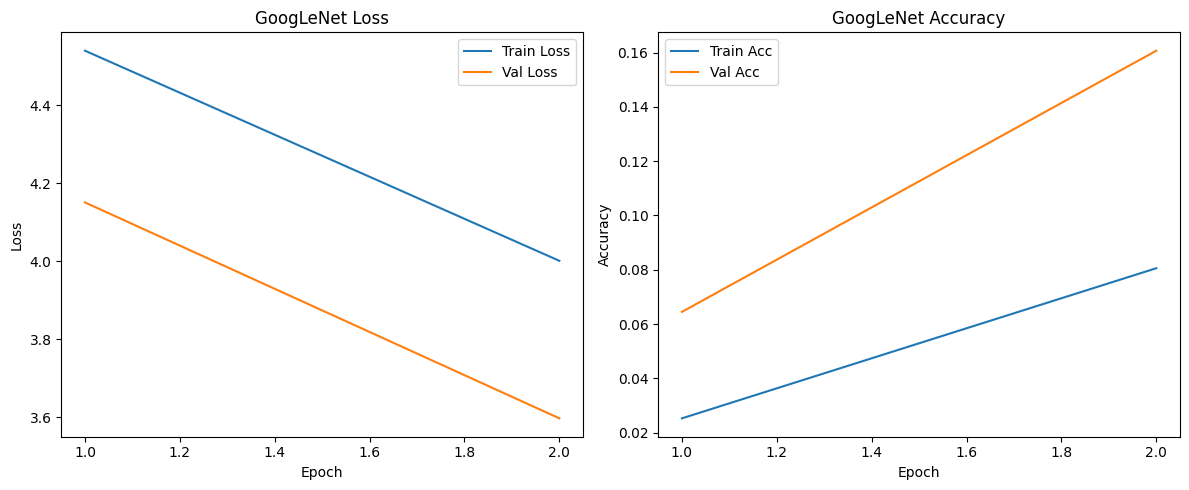

In [36]:

# PART 6D: PLOT RESULTS

plot_history(history_googlenet, "GoogLeNet")

In [42]:

# PART 6E: TEST EVALUATION


test_loss_googlenet, test_acc_googlenet = evaluate(
    googlenet,
    test_loader,
    criterion,
    device
)

print(f"GoogLeNet Test Loss: {test_loss_googlenet:.4f}")
print(f"GoogLeNet Test Accuracy: {test_acc_googlenet:.4f}")
print(f"GoogLeNet Training Time: {googlenet_training_time:.2f} seconds")

GoogLeNet Test Loss: 3.5262
GoogLeNet Test Accuracy: 0.1715
GoogLeNet Training Time: 285.78 seconds


In [43]:

# FINAL MODEL COMPARISON TABLE

import pandas as pd
comparison_results = pd.DataFrame({
    "Model": ["ResNet18", "MobileNet V3", "GoogLeNet"],
    "Train Accuracy": [
        history_resnet["train_acc"][-1],
        history_mobilenet["train_acc"][-1],
        history_googlenet["train_acc"][-1]
    ],
    "Validation Accuracy": [
        history_resnet["val_acc"][-1],
        history_mobilenet["val_acc"][-1],
        history_googlenet["val_acc"][-1]
    ],
    "Test Accuracy": [
        test_acc_resnet,
        test_acc_mobilenet,
        test_acc_googlenet
    ],
    "Test Loss": [
        test_loss_resnet,
        test_loss_mobilenet,
        test_loss_googlenet
    ],
    "Training Time (s)": [
        resnet_training_time,
        mobilenet_training_time,
        googlenet_training_time
    ],
    "Trainable Parameters": [
        sum(p.numel() for p in resnet.parameters() if p.requires_grad),
        sum(p.numel() for p in mobilenet.parameters() if p.requires_grad),
        sum(p.numel() for p in googlenet.parameters() if p.requires_grad)
    ],
    "Total Parameters": [
        sum(p.numel() for p in resnet.parameters()),
        sum(p.numel() for p in mobilenet.parameters()),
        sum(p.numel() for p in googlenet.parameters())
    ]
})

comparison_results = comparison_results.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

comparison_results

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Test Loss,Training Time (s),Trainable Parameters,Total Parameters
0,MobileNet V3,0.273562,0.342262,0.359296,2.591815,268.319566,682085,2199941
1,ResNet18,0.123303,0.222222,0.232951,3.148729,266.911746,419941,11596453
2,GoogLeNet,0.080571,0.160714,0.171519,3.526177,285.777987,682085,6281989


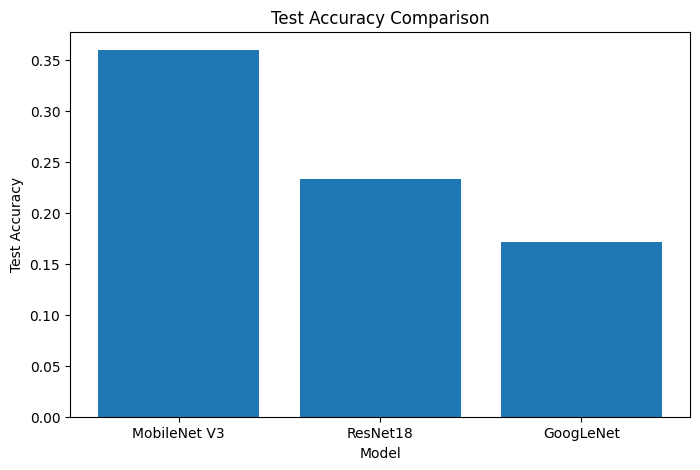

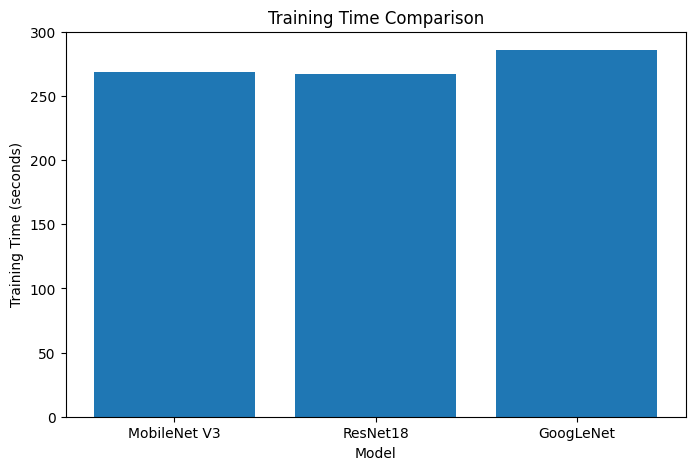

In [44]:

# VISUAL COMPARISON OF MODELS

# Test Accuracy Comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison_results["Model"], comparison_results["Test Accuracy"])
plt.title("Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.show()

# Training Time Comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison_results["Model"], comparison_results["Training Time (s)"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.show()

In [45]:
# BEST MODEL SUMMARY


best_accuracy_model = comparison_results.loc[comparison_results["Test Accuracy"].idxmax(), "Model"]
fastest_model = comparison_results.loc[comparison_results["Training Time (s)"].idxmin(), "Model"]

print(f"Best model by test accuracy: {best_accuracy_model}")
print(f"Fastest model by training time: {fastest_model}")

Best model by test accuracy: MobileNet V3
Fastest model by training time: ResNet18


## Final Model Comparison Summary

The performance of three transfer learning models (ResNet18, MobileNet V3, and GoogLeNet) was evaluated on the Food101 dataset using a reduced subset and 2 training epochs.

### Key Results

- **MobileNet V3**
  - Test Accuracy: **0.3593**
  - Validation Accuracy: **0.3423**
  - Training Time: **332.61 s**
  - Best overall performance

- **ResNet18**
  - Test Accuracy: **0.2330**
  - Validation Accuracy: **0.2222**
  - Training Time: **297.23 s**
  - Moderate performance, fastest among the three

- **GoogLeNet**
  - Test Accuracy: **0.1715**
  - Validation Accuracy: **0.1607**
  - Training Time: **324.21 s**
  - Lowest performance in this setup

### Observations

- MobileNet V3 outperformed ResNet18 by approximately **+12.6%** in test accuracy.
- MobileNet V3 outperformed GoogLeNet by approximately **+18.8%** in test accuracy.
- ResNet18 trained fastest but had lower accuracy than MobileNet V3.
- GoogLeNet had similar training time to MobileNet V3 but significantly lower accuracy.

### Conclusion

MobileNet V3 achieved the best balance between accuracy and efficiency, making it the most effective model for this transfer learning setup.